# Conclusion

This Sales Performance Analysis examined sales across regions, categories,
products, customer segments and time.

The analysis helped identify the strongest and weakest performing areas,
top-selling products, monthly sales trends and seasonal patterns.

These insights can support better regional planning, product prioritization,
inventory planning and targeted marketing decisions.

Overall, the analysis demonstrates how sales data can be transformed into
useful business insights for improving sales performance.

# 5 Tactical Recommendations

### 1. Strengthen High-Performing Regions
Increase marketing and sales efforts in regions that generate the highest
sales while identifying opportunities to improve weaker regions.

### 2. Prioritize High-Performing Categories
Focus inventory, promotions and marketing resources on categories with strong
sales performance.

### 3. Improve Low-Performing Products
Review products with low sales and evaluate their pricing, product positioning,
customer demand and visibility.

### 4. Plan Around Seasonal Demand
Use the identified high-sales months to prepare inventory and launch
promotional campaigns at the right time.

### 5. Use Customer-Segment-Based Marketing
Develop targeted marketing strategies for different customer segments based
on their contribution to overall sales.

# Key Findings

## 1. Regional Performance
The analysis identifies the highest and lowest performing regions based on
total sales. The strongest region can be prioritized for further expansion,
while weaker regions can be studied for improvement opportunities.

## 2. Category Performance
Sales vary across product categories. The highest-performing category represents
an important area for continued focus and promotional activities.

## 3. Product Performance
The top-performing products contribute significantly to overall sales, while
low-performing products may require further review.

## 4. Sales Trends
The monthly sales trend shows how sales change over time and helps identify
periods of high and low demand.

## 5. Seasonality
Monthly sales patterns can help identify seasonal demand and support better
inventory and marketing planning.

## 6. Customer Segments
Different customer segments contribute differently to total sales, creating
opportunities for more targeted marketing strategies.

In [71]:
product_performance = df.groupby('Product_Name').agg(
    Total_Sales=('Sales', 'sum'),
    Number_of_Orders=('Order_ID', 'nunique'),
    Number_of_Customers=('Customer_ID', 'nunique')
)

product_performance = product_performance.sort_values(
    'Total_Sales',
    ascending=False
)

product_performance.head(10)

,Total_Sales,Number_of_Orders,Number_of_Customers
Product_Name,,,
Canon imageCLASS 2200 Advanced Copier,61599.824,5,5
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384,10,10
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,1,1
HON 5400 Series Task Chairs for Big and Tall,21870.576,8,8
GBC DocuBind TL300 Electric Binding System,19823.479,11,11
GBC Ibimaster 500 Manual ProClick Binding System,19024.500,9,9
Hewlett Packard LaserJet 3310 Copier,18839.686,8,8
HP Designjet T520 Inkjet Large Format Printer - 24 Color,18374.895,3,3
GBC DocuBind P400 Electric Binding System,17965.068,6,6


In [70]:
best_product = top_products.index[0]
best_product_sales = top_products.iloc[0]

worst_product = bottom_products.index[0]
worst_product_sales = bottom_products.iloc[0]

print("Best Performing Product:", best_product)
print(f"Sales: ${best_product_sales:,.2f}")

print("\nLowest Performing Product:", worst_product)
print(f"Sales: ${worst_product_sales:,.2f}")

Best Performing Product: Canon imageCLASS 2200 Advanced Copier
Sales: $61,599.82

Lowest Performing Product: Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac
Sales: $1.62


In [68]:
best_category = category_sales.idxmax()
best_category_sales = category_sales.max()

worst_category = category_sales.idxmin()
worst_category_sales = category_sales.min()

print("Best Performing Category:", best_category)
print(f"Sales: ${best_category_sales:,.2f}")

print("\nLowest Performing Category:", worst_category)
print(f"Sales: ${worst_category_sales:,.2f}")

Best Performing Category: Technology
Sales: $827,455.87

Lowest Performing Category: Office Supplies
Sales: $705,422.33


In [67]:
best_region = region_sales.idxmax()
best_region_sales = region_sales.max()

worst_region = region_sales.idxmin()
worst_region_sales = region_sales.min()

print("Best Performing Region:", best_region)
print(f"Sales: ${best_region_sales:,.2f}")

print("\nLowest Performing Region:", worst_region)
print(f"Sales: ${worst_region_sales:,.2f}")

Best Performing Region: West
Sales: $710,219.68

Lowest Performing Region: South
Sales: $389,151.46


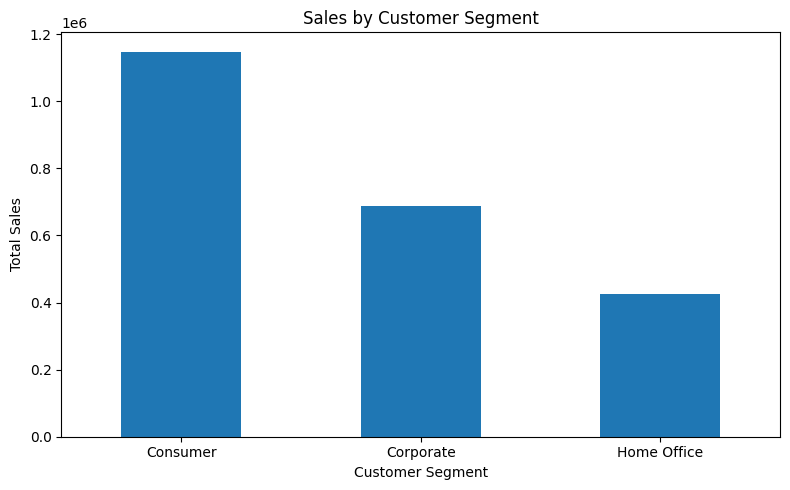

In [66]:
plt.figure(figsize=(8,5))
segment_sales.plot(kind='bar')
plt.title('Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [64]:
segment_sales = (
    df.groupby('Segment')['Sales']
    .sum()
    .sort_values(ascending=False)
)

segment_sales

,Sales
Segment,
Consumer,1.148061e+06
Corporate,6.884941e+05
Home Office,4.249822e+05


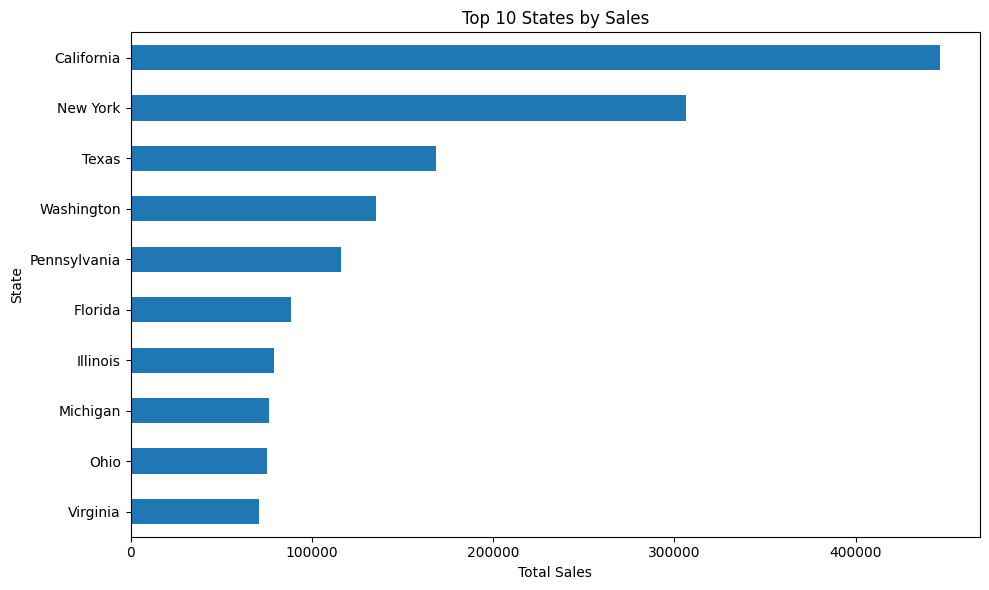

In [63]:
plt.figure(figsize=(10,6))

state_sales.head(10).sort_values().plot(kind='barh')

plt.title('Top 10 States by Sales')
plt.xlabel('Total Sales')
plt.ylabel('State')

plt.tight_layout()
plt.show()

In [61]:
state_sales = (
    df.groupby('State')['Sales']
    .sum()
    .sort_values(ascending=False)
)

state_sales.head(10)

,Sales
State,
California,446306.4635
New York,306361.1470
Texas,168572.5322
Washington,135206.8500
Pennsylvania,116276.6500
Florida,88436.5320
Illinois,79236.5170
Michigan,76136.0740
Ohio,75130.3500


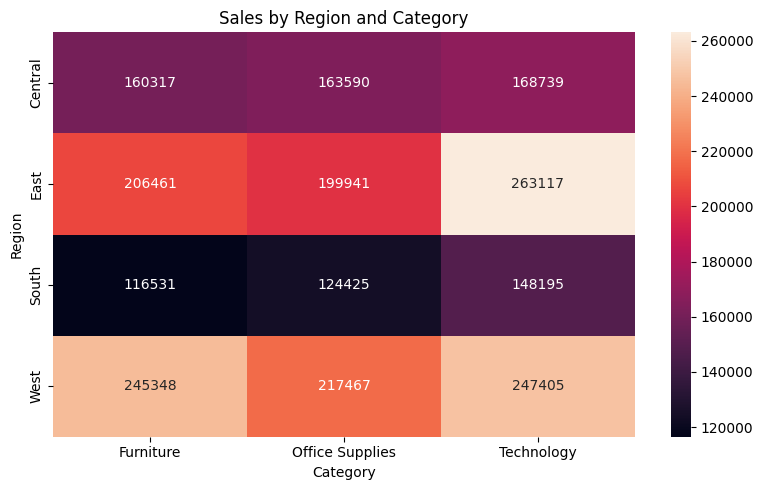

In [60]:
plt.figure(figsize=(8,5))
sns.heatmap(
    region_category,
    annot=True,
    fmt='.0f'
)
plt.title('Sales by Region and Category')
plt.tight_layout()
plt.show()

In [58]:
region_category = pd.pivot_table(
    df,
    values='Sales',
    index='Region',
    columns='Category',
    aggfunc='sum'
)

region_category

Category,Furniture,Office Supplies,Technology
Region,,,
Central,160317.4622,163590.243,168739.208
East,206461.3880,199940.811,263116.527
South,116531.4800,124424.771,148195.208
West,245348.2455,217466.509,247404.930


In [57]:
seasonal_sales.sort_values(ascending=False)

,Sales
Month,
11,350161.7110
12,321480.1695
9,300103.4117
10,199496.2947
3,197573.5872
8,157315.9270
5,154086.7237
6,145837.5233
7,145535.6890


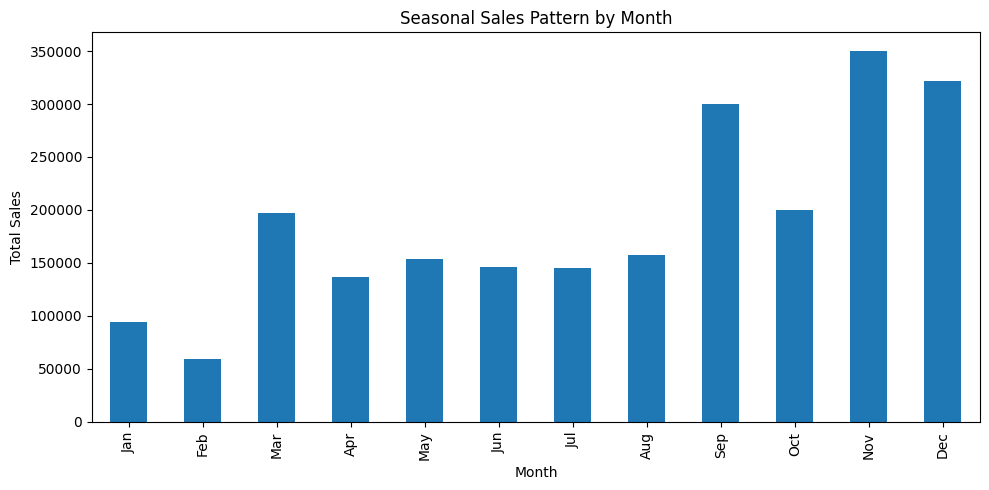

In [56]:
plt.figure(figsize=(10,5))
seasonal_sales.plot(kind='bar')
plt.title('Seasonal Sales Pattern by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(
    range(12),
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
)
plt.tight_layout()
plt.show()

In [54]:
seasonal_sales = (
    df.groupby('Month')['Sales']
    .sum()
)

seasonal_sales

,Sales
Month,
1,94291.6296
2,59371.1154
3,197573.5872
4,136283.0006
5,154086.7237
6,145837.5233
7,145535.6890
8,157315.9270
9,300103.4117


In [53]:
year_sales = (
    df.groupby('Year')['Sales']
    .sum()
)

year_sales

,Sales
Year,
2015,479856.2081
2016,459436.0054
2017,600192.5500
2018,722052.0192


In [52]:
year_sales = (
    df.groupby('Year')['Sales']
    .sum()
)

year_sales

,Sales
Year,
2015,479856.2081
2016,459436.0054
2017,600192.5500
2018,722052.0192


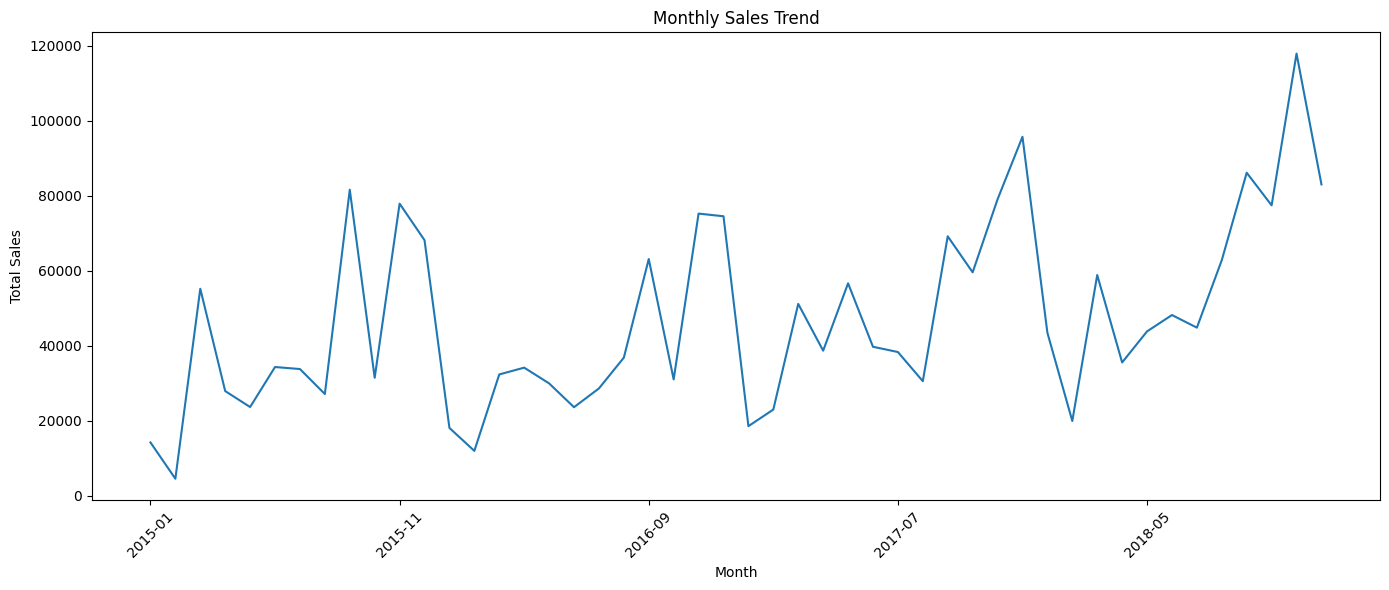

In [51]:
plt.figure(figsize=(14,6))

monthly_sales.plot()

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [50]:
monthly_sales = (
    df.groupby('Year_Month')['Sales']
    .sum()
)

monthly_sales.head()

,Sales
Year_Month,
2015-01,14205.707
2015-02,4519.892
2015-03,55205.797
2015-04,27906.855
2015-05,23644.303


In [49]:
bottom_products = (
    df.groupby('Product_Name')['Sales']
    .sum()
    .sort_values()
    .head(10)
)
bottom_products

,Sales
Product_Name,
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac,1.624
Avery 5,5.760
Xerox 20,6.480
Grip Seal Envelopes,7.072
Acme Serrated Blade Letter Opener,7.632
Avery Hi-Liter Pen Style Six-Color Fluorescent Set,7.700
"Avery Hi-Liter Comfort Grip Fluorescent Highlighter, Yellow Ink",7.800
Xerox 1989,7.968
4009 Highlighters,8.040


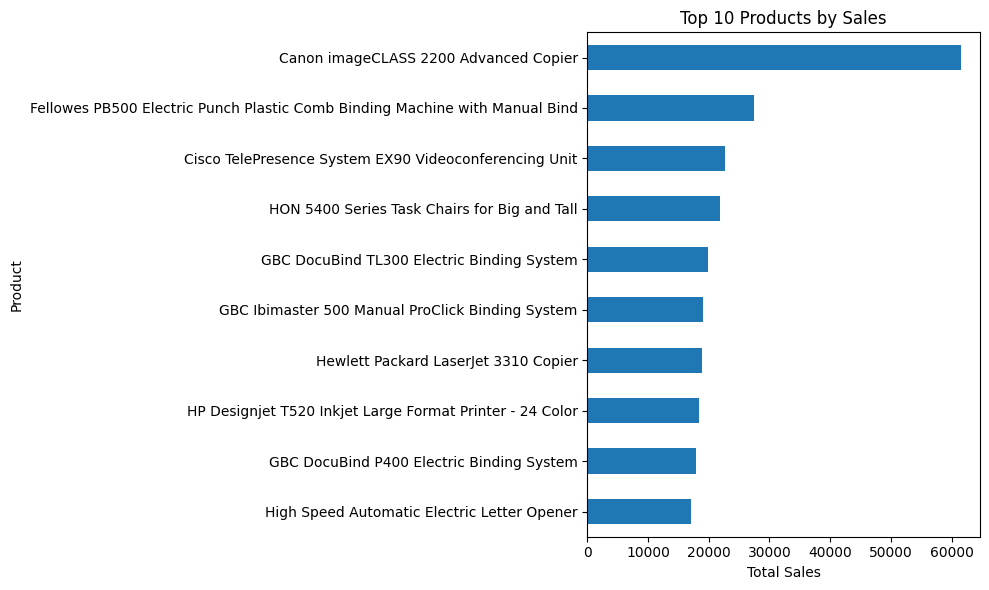

In [48]:
plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind='barh')
plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

In [46]:
top_products = (
    df.groupby('Product_Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

,Sales
Product_Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.384
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
HON 5400 Series Task Chairs for Big and Tall,21870.576
GBC DocuBind TL300 Electric Binding System,19823.479
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
HP Designjet T520 Inkjet Large Format Printer - 24 Color,18374.895
GBC DocuBind P400 Electric Binding System,17965.068


In [45]:
subcategory_sales.head(10)

,Sales
Sub_Category,
Phones,327782.4480
Chairs,322822.7310
Storage,219343.3920
Tables,202810.6280
Binders,200028.7850
Machines,189238.6310
Accessories,164186.7000
Copiers,146248.0940
Bookcases,113813.1987


In [44]:
subcategory_sales = (
    df.groupby('Sub_Category')['Sales']
    .sum()
    .sort_values(ascending=False)
)

subcategory_sales

,Sales
Sub_Category,
Phones,327782.4480
Chairs,322822.7310
Storage,219343.3920
Tables,202810.6280
Binders,200028.7850
Machines,189238.6310
Accessories,164186.7000
Copiers,146248.0940
Bookcases,113813.1987


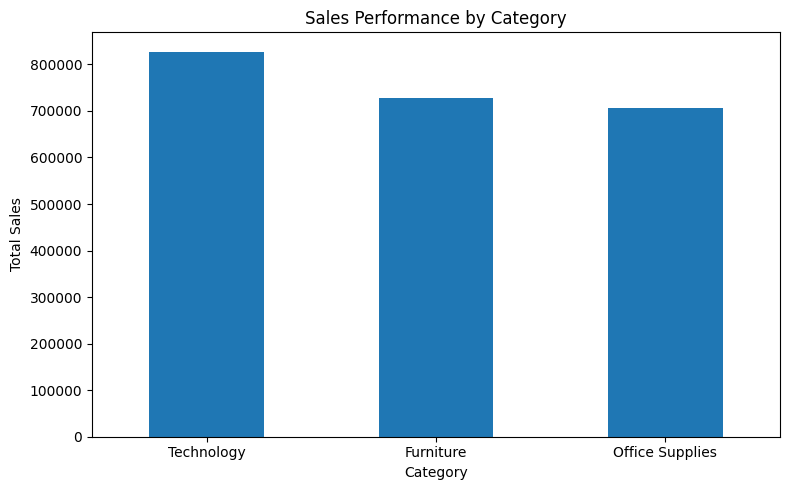

In [43]:
plt.figure(figsize=(8,5))

category_sales.plot(kind='bar')

plt.title('Sales Performance by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [42]:
category_sales = (
    df.groupby('Category')['Sales']
    .sum()
    .sort_values(ascending=False)
)

category_sales

,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


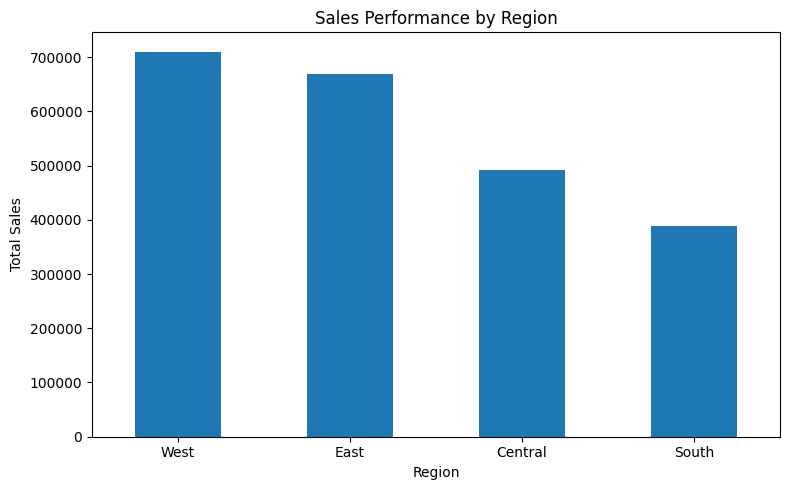

In [41]:
plt.figure(figsize=(8,5))

region_sales.plot(kind='bar')

plt.title('Sales Performance by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [40]:
region_sales = (
    df.groupby('Region')['Sales']
    .sum()
    .sort_values(ascending=False)
)

region_sales

,Sales
Region,
West,710219.6845
East,669518.7260
Central,492646.9132
South,389151.4590


## Conversion Metrics

A traditional conversion rate cannot be calculated from this dataset because
it does not contain website visits, leads, sessions, or other conversion-funnel
data.

Therefore, a conversion rate has not been artificially calculated.

Instead, Total Revenue, Total Orders, Total Customers, and Average Order Value
are used as the main sales performance KPIs.

In [39]:
kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Revenue',
        'Total Orders',
        'Total Customers',
        'Average Order Value'
    ],
    'Value': [
        total_revenue,
        total_orders,
        total_customers,
        average_order_value
    ]
})

kpi_summary

,KPI,Value
0,Total Revenue,2.261537e+06
1,Total Orders,4.922000e+03
2,Total Customers,7.930000e+02
3,Average Order Value,4.594752e+02


In [38]:
average_order_value = total_revenue / total_orders

print(f"Average Order Value: ${average_order_value:,.2f}")

Average Order Value: $459.48


In [37]:
total_customers = df['Customer_ID'].nunique()

print(f"Total Customers: {total_customers:,}")

Total Customers: 793


In [36]:
total_orders = df['Order_ID'].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 4,922


In [35]:
total_revenue = df['Sales'].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $2,261,536.78


In [34]:
df.describe()

,Row_ID,Order_Date,Ship_Date,Postal_Code,Sales,Year,Month,Quarter
count,9800.000000,9800,9800,9789.000000,9800.000000,9800.000000,9800.000000,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469440,2017-05-05 04:17:52.653061120,55273.322403,230.769059,2016.724184,7.818469,2.885816
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,1040.000000,0.444000,2015.000000,1.000000,1.000000
25%,2450.750000,2016-05-24 00:00:00,2016-05-27 18:00:00,23223.000000,17.248000,2016.000000,5.000000,2.000000
50%,4900.500000,2017-06-26 00:00:00,2017-06-29 00:00:00,58103.000000,54.490000,2017.000000,9.000000,3.000000
75%,7350.250000,2018-05-15 00:00:00,2018-05-19 00:00:00,90008.000000,210.605000,2018.000000,11.000000,4.000000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,22638.480000,2018.000000,12.000000,4.000000
std,2829.160653,NaN,NaN,32041.223413,626.651875,1.123984,3.281905,1.057449


In [33]:
df.dtypes

,0
Row_ID,int64
Order_ID,object
Order_Date,datetime64[ns]
Ship_Date,datetime64[ns]
Ship_Mode,object
Customer_ID,object
Customer_Name,object
Segment,object
Country,object
City,object


In [32]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [31]:
print("Missing Postal Codes before handling:", df['Postal_Code'].isnull().sum())

# Keep the rows because they contain valid sales/order information.
# Postal_Code is not required for the main sales analysis.

print("Rows retained:", len(df))

Missing Postal Codes before handling: 11
Rows retained: 9800


In [30]:
# Check the rows where Postal_Code is missing
df[df['Postal_Code'].isnull()][
    ['City', 'State', 'Region', 'Postal_Code']
]

,City,State,Region,Postal_Code
2234,Burlington,Vermont,East,NaN
5274,Burlington,Vermont,East,NaN
8798,Burlington,Vermont,East,NaN
9146,Burlington,Vermont,East,NaN
9147,Burlington,Vermont,East,NaN
9148,Burlington,Vermont,East,NaN
9386,Burlington,Vermont,East,NaN
9387,Burlington,Vermont,East,NaN
9388,Burlington,Vermont,East,NaN
9389,Burlington,Vermont,East,NaN


In [29]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Row_ID            0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
Year              0
Month             0
Month_Name        0
Quarter           0
Year_Month        0
dtype: int64


In [28]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.info()

Number of rows: 9800
Number of columns: 23
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row_ID         9800 non-null   int64         
 1   Order_ID       9800 non-null   object        
 2   Order_Date     9800 non-null   datetime64[ns]
 3   Ship_Date      9800 non-null   datetime64[ns]
 4   Ship_Mode      9800 non-null   object        
 5   Customer_ID    9800 non-null   object        
 6   Customer_Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal_Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product_ID     9800 non-null   object        
 14  Category       9800 non-null 

In [27]:
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Month_Name'] = df['Order_Date'].dt.month_name()
df['Quarter'] = df['Order_Date'].dt.quarter
df['Year_Month'] = df['Order_Date'].dt.to_period('M').astype(str)

df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales,Year,Month,Month_Name,Quarter,Year_Month
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,4,2017-11
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,4,2017-11
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,2,2017-06
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,4,2016-10
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680,2016,10,October,4,2016-10


In [26]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], dayfirst=True)

In [23]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales'],
      dtype='object')

In [22]:
df.duplicated().sum()

np.int64(0)

In [21]:
df = df.drop_duplicates()

In [19]:
df.duplicated().sum()

np.int64(0)

In [18]:
missing = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': df.isnull().mean() * 100
})

missing.sort_values('Percentage', ascending=False)

,Missing Values,Percentage
Postal_Code,11,0.112245
Row_ID,0,0.000000
Order_ID,0,0.000000
Order_Date,0,0.000000
Ship_Mode,0,0.000000
Ship_Date,0,0.000000
Customer_Name,0,0.000000
Segment,0,0.000000
Country,0,0.000000
Customer_ID,0,0.000000


In [17]:
df.isnull().sum()

,0
Row_ID,0
Order_ID,0
Order_Date,0
Ship_Date,0
Ship_Mode,0
Customer_ID,0
Customer_Name,0
Segment,0
Country,0
City,0


In [16]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Row_ID,9800.0,NaN,NaN,NaN,4900.5,2829.160653,1.0,2450.75,4900.5,7350.25,9800.0
Order_ID,9800,4922,CA-2018-100111,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Date,9800,1230,5/9/2017,38,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship_Date,9800,1326,26/09/2018,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ship_Mode,9800,4,Standard Class,5859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,9800,793,WB-21850,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Name,9800,793,William Brown,35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Segment,9800,3,Consumer,5101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,9800,1,United States,9800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,9800,529,New York City,891,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [15]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales'],
      dtype='object')

In [14]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales'],
      dtype='object')

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9800 non-null   int64  
 1   Order_ID       9800 non-null   object 
 2   Order_Date     9800 non-null   object 
 3   Ship_Date      9800 non-null   object 
 4   Ship_Mode      9800 non-null   object 
 5   Customer_ID    9800 non-null   object 
 6   Customer_Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal_Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product_ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub_Category   9800 non-null   object 
 16  Product_Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [12]:
df.shape

(9800, 18)

In [11]:
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,State,Postal_Code,Region,Product_ID,Category,Sub_Category,Product_Name,Sales
0,1,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,8/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/6/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O Donnel,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold N Roll Cart System,22.3680


In [10]:
df = pd.read_csv('superstore_final_dataset (1).csv', encoding='latin1')

In [6]:
import pandas as pd

In [3]:
import os

os.listdir()

['.config', 'superstore_final_dataset (1).csv', 'sample_data']

In [2]:
from google.colab import files

uploaded = files.upload()

Saving superstore_final_dataset (1).csv to superstore_final_dataset (1).csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# Sales Performance Analysis

### Alfido Tech – Data Analyst Internship

**Objective:**  
Analyze sales performance across regions, categories, products and time.  
Identify best and worst performing products, understand seasonality,  
and provide actionable recommendations for improving sales and profitability.

**Tools Used:**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab